In [43]:
!pip install selenium

import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options

chrome_options = Options()
chrome_options.add_argument("--lang=zh-CN")  # 设置中文语言
browser = webdriver.Chrome(options=chrome_options)

browser.get("https://cn.investing.com/indices/shanghai-composite-historical-data")

table_xpath = '//*[@id="__next"]/div[2]/div[2]/div[2]/div[1]/div[2]'
table = WebDriverWait(browser,30).until(
    EC.presence_of_element_located((By.XPATH, table_xpath))
)
rows=table.find_elements(By.TAG_NAME,"tr")


In [44]:
data=[]
for row in rows[1:]:  # 跳过表头
    columns=row.find_elements(By.TAG_NAME,"td")
    column_data=[col.text for col in columns]
    
    while len(column_data) < 7:
        column_data.append("")
    print(column_data)  
    data.append(column_data)
        


['1月 14, 2025', '3,240.94', '3,165.16', '3,245.22', '3,159.43', '46.92B', '+2.54%']
['1月 13, 2025', '3,160.75', '3,148.83', '3,172.70', '3,140.98', '37.27B', '-0.25%']
['1月 10, 2025', '3,168.52', '3,211.71', '3,220.11', '3,168.52', '40.37B', '-1.33%']
['1月 09, 2025', '3,211.39', '3,220.72', '3,228.97', '3,205.91', '38.29B', '-0.58%']
['1月 08, 2025', '3,230.17', '3,218.86', '3,246.29', '3,175.72', '47.29B', '+0.02%']
['1月 07, 2025', '3,229.64', '3,203.31', '3,230.85', '3,190.46', '40.97B', '+0.71%']
['1月 06, 2025', '3,206.92', '3,209.78', '3,219.49', '3,185.46', '43.10B', '-0.14%']
['1月 03, 2025', '3,211.43', '3,267.08', '3,273.57', '3,205.78', '51.76B', '-1.57%']
['1月 02, 2025', '3,262.56', '3,347.94', '3,351.72', '3,242.09', '56.14B', '-2.66%']
['12月 31, 2024', '3,351.76', '3,406.97', '3,413.45', '3,351.76', '50.27B', '-1.63%']
['12月 30, 2024', '3,407.33', '3,395.40', '3,412.84', '3,394.96', '45.53B', '+0.21%']
['12月 27, 2024', '3,400.14', '3,397.29', '3,418.95', '3,388.32', '50.05B',

In [47]:
df = pd.DataFrame(data, columns=["日期", "收盘", "开盘", "高", "低", "涨跌幅", "交易量"])
print(df)
df.to_csv("stock_data.csv", index=False)
print("准备关闭浏览器...")
browser.quit()

              日期        收盘        开盘         高         低     涨跌幅     交易量
0    1月 14, 2025  3,240.94  3,165.16  3,245.22  3,159.43  46.92B  +2.54%
1    1月 13, 2025  3,160.75  3,148.83  3,172.70  3,140.98  37.27B  -0.25%
2    1月 10, 2025  3,168.52  3,211.71  3,220.11  3,168.52  40.37B  -1.33%
3    1月 09, 2025  3,211.39  3,220.72  3,228.97  3,205.91  38.29B  -0.58%
4    1月 08, 2025  3,230.17  3,218.86  3,246.29  3,175.72  47.29B  +0.02%
5    1月 07, 2025  3,229.64  3,203.31  3,230.85  3,190.46  40.97B  +0.71%
6    1月 06, 2025  3,206.92  3,209.78  3,219.49  3,185.46  43.10B  -0.14%
7    1月 03, 2025  3,211.43  3,267.08  3,273.57  3,205.78  51.76B  -1.57%
8    1月 02, 2025  3,262.56  3,347.94  3,351.72  3,242.09  56.14B  -2.66%
9   12月 31, 2024  3,351.76  3,406.97  3,413.45  3,351.76  50.27B  -1.63%
10  12月 30, 2024  3,407.33  3,395.40  3,412.84  3,394.96  45.53B  +0.21%
11  12月 27, 2024  3,400.14  3,397.29  3,418.95  3,388.32  50.05B  +0.06%
12  12月 26, 2024  3,398.08  3,389.34  3,401.10  3,3

In [72]:
df=pd.read_csv('stock_data.csv',encoding='utf-8')
print(df.isnull().sum())
df.fillna(0,inplace=True)#用0填充缺失值

month_map = {'1月': '01', '12月': '12'}
df['日期'] = df['日期'].replace(month_map, regex=True)
df['日期'] = df['日期'].str.replace(',', '').str.strip()
df['日期'] = pd.to_datetime(df['日期'], format='%m %d %Y')
df['收盘'] = df['收盘'].str.replace(',', '').astype(float)
df['开盘'] = df['开盘'].str.replace(',', '').astype(float)
df['高'] = df['高'].str.replace(',', '').astype(float)
df['低'] = df['低'].str.replace(',', '').astype(float)
df['涨跌幅'] = df['涨跌幅'].str.replace('%', '').str.strip()
df['涨跌幅'] = df['涨跌幅'].apply(lambda x: float(x.replace('B', '')) * 1e9 if 'B' in x else
                                      (float(x.replace('M', '')) * 1e6 if 'M' in x else float(x)))
print(df.dtypes)
df.to_csv('cleaned_stock_data.csv',index=False)

print(df.head())

日期     0
收盘     0
开盘     0
高      0
低      0
涨跌幅    0
交易量    0
dtype: int64
日期     datetime64[ns]
收盘            float64
开盘            float64
高             float64
低             float64
涨跌幅           float64
交易量            object
dtype: object
          日期       收盘       开盘        高        低           涨跌幅     交易量
0 2025-01-14  3240.94  3165.16  3245.22  3159.43  4.692000e+10  +2.54%
1 2025-01-13  3160.75  3148.83  3172.70  3140.98  3.727000e+10  -0.25%
2 2025-01-10  3168.52  3211.71  3220.11  3168.52  4.037000e+10  -1.33%
3 2025-01-09  3211.39  3220.72  3228.97  3205.91  3.829000e+10  -0.58%
4 2025-01-08  3230.17  3218.86  3246.29  3175.72  4.729000e+10  +0.02%


In [74]:
average_change = df['涨跌幅'].mean()
print(f"平均涨跌幅: {average_change:.2f}%")

平均涨跌幅: 48160476190.48%


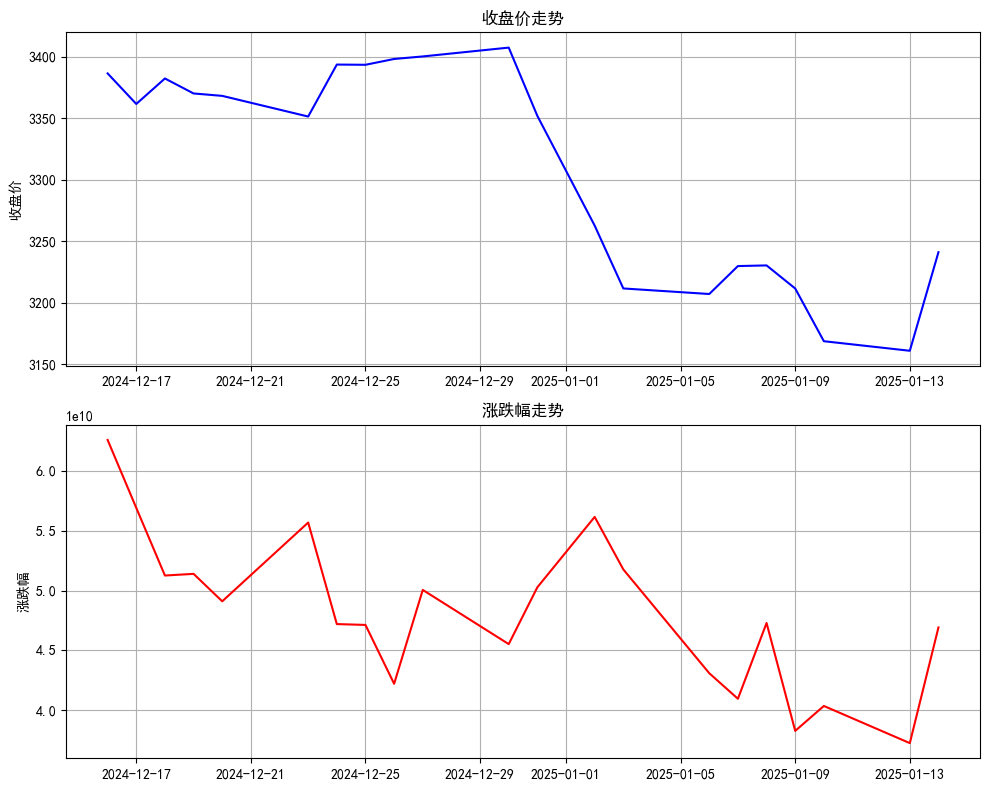

In [76]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']

ax[0].plot(df['日期'], df['收盘'], color='blue', label='收盘价')
ax[0].set_title('收盘价走势')
ax[0].set_ylabel('收盘价')
ax[0].grid(True)

ax[1].plot(df['日期'], df['涨跌幅'], color='red', label='涨跌幅')
ax[1].set_title('涨跌幅走势')
ax[1].set_ylabel('涨跌幅')
ax[1].grid(True)

plt.tight_layout()
plt.show()

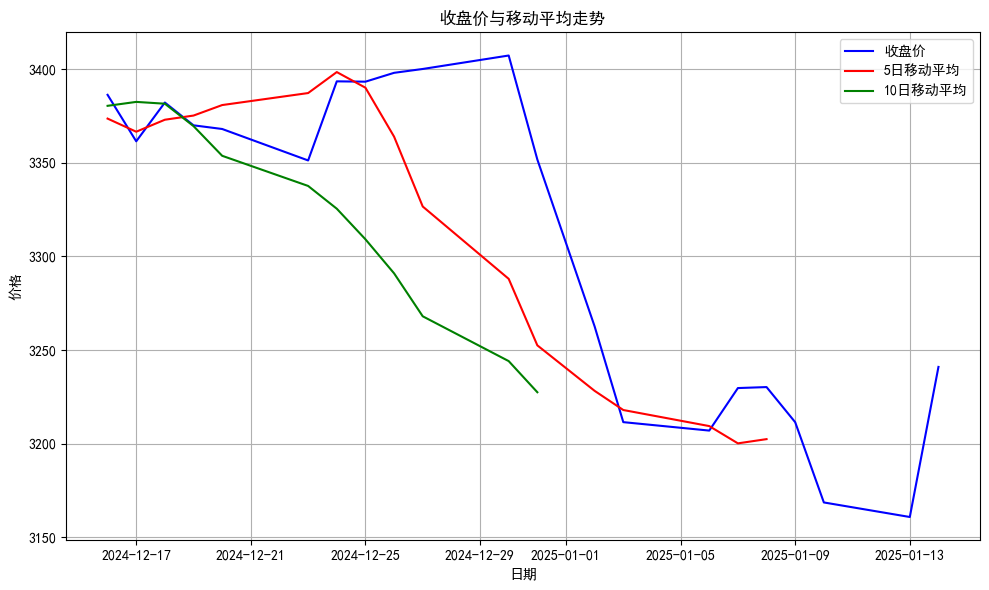

In [80]:
df['5日移动平均'] = df['收盘'].rolling(window=5).mean()
df['10日移动平均'] = df['收盘'].rolling(window=10).mean()

plt.figure(figsize=(10, 6))
plt.plot(df['日期'], df['收盘'], label='收盘价', color='blue')
plt.plot(df['日期'], df['5日移动平均'], label='5日移动平均', color='red')
plt.plot(df['日期'], df['10日移动平均'], label='10日移动平均', color='green')

plt.title('收盘价与移动平均走势')
plt.xlabel('日期')
plt.ylabel('价格')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


D:\anacoda python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


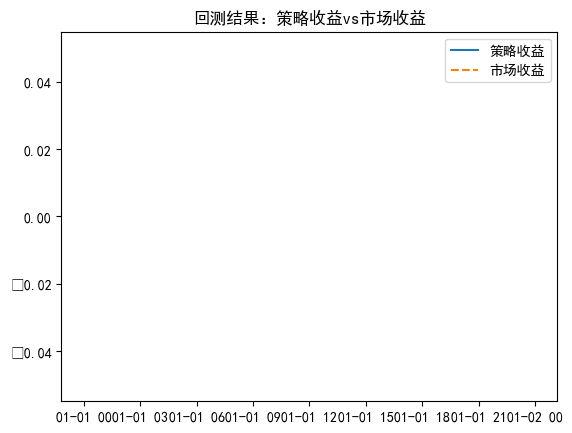

In [90]:
df['Signal'] = 0
df.loc[df['5日移动平均']>df['10日移动平均'],'Signal']=1  #买入信号
df.loc[df['5日移动平均']<df['10日移动平均'],'Signal']=-1  #卖出信号
df['Daily_Return']=df['收盘'].pct_change()
df['Strategy_Return']=df['Signal'].shift(1)*df['Daily_Return']

df['Cumulative_Strategy_Return']=(1+df['Strategy_Return']).cumprod()
df['Cumulative_Market_Return']=(1+df['Daily_Return']).cumprod()

plt.plot(df['日期'],df['Cumulative_Strategy_Return'],label='策略收益')
plt.plot(df['日期'],df['Cumulative_Market_Return'],label='市场收益',linestyle='--')
plt.title('回测结果：策略收益vs市场收益')
plt.legend()
plt.show()


In [88]:
df['price_change']=df['收盘'].diff()
df['gain']=df['price_change'].where(df['price_change']>0,0)
df['loss']=-df['price_change'].where(df['price_change']<0,0)

df['average_gain']=df['gain'].rolling(window=14).mean()
df['average_loss']=df['loss'].rolling(window=14).mean()

df['RS']=df['average_gain']/df['average_loss']
df['RSI']=100-(100/(1+df['RS']))

df = df.dropna(subset=['RSI'])
print(df[['日期','RSI']])

Empty DataFrame
Columns: [日期, RSI]
Index: []


In [ ]:
import tkinter as tk
from tkinter import filedialog
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

def load_file():
    file_path = filedialog.askopenfilename(filetypes=[("CSV Files", "*.csv")])
    if file_path:
        df = pd.read_csv(file_path)
        plot_data(df)

def plot_data(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['日期'], df['收盘'], label='收盘价', color='blue')
    ax.set_title('收盘价走势')
    ax.set_xlabel('日期')
    ax.set_ylabel('收盘价')
    ax.grid(True)

    # 将图表嵌入Tkinter界面
    canvas = FigureCanvasTkAgg(fig, master=window)
    canvas.draw()
    canvas.get_tk_widget().pack()


window = tk.Tk()
window.title('股票分析系统')

load_button = tk.Button(window, text="加载股票数据", command=load_file)
load_button.pack()

window.mainloop()
